W pliku punkty.csv1 znajduje się zbiór 106 par liczb ze
zbioru D:= {(ti, yi) : 0 ≤i ≤105}. Wartości te są odczytami z aparatury mierzącej
pewną wielkość fizyczną f zachowującą się – jak mówi teoria – zgodnie ze wzorem
f (t) = 2.14(t + 1.4)(t + 5.3)(t−0.44).
Z tym jednak, że aparatura dokonuje pomiarów z błędem wyrażonym rozkładem nor-
malnym o średniej 0 i odchyleniu standardowym ±0.2, czyli
yi = f (ti) + N (0, 0.22) (0 ≤i ≤105).

Narysuj wykres funkcji f i zbiór D.

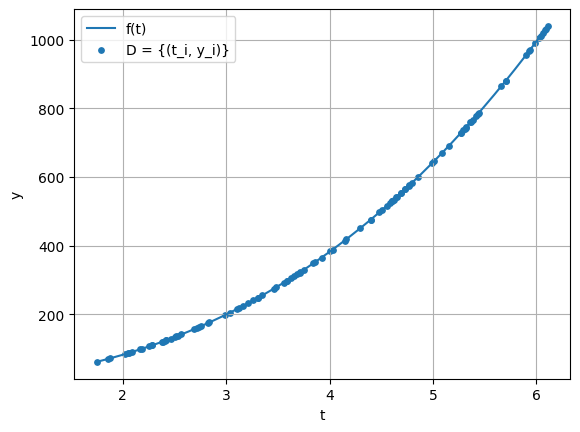

In [6]:
import numpy as np
import matplotlib.pyplot as plt

t, y = np.genfromtxt("punkty.csv", delimiter=",", unpack=True)

def f(t):
    return 2.14 * (t + 1.4) * (t + 5.3) * (t - 0.44)

idx = np.argsort(t)
t, y = t[idx], y[idx]
x = np.linspace(t.min(), t.max(), 2000)

plt.plot(x, f(x), label="f(t)")
plt.scatter(t, y, s=15, label="D = {(t_i, y_i)}")
plt.xlabel("t")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()


Wyznacz i narysuj wielomian interpolacyjny dla danych z pliku punkty.csv. Co
obserwujemy?

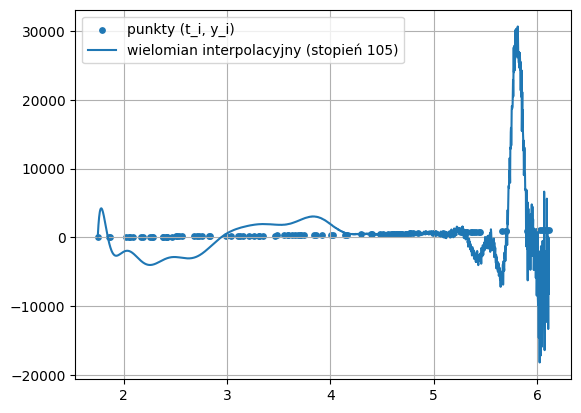

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

t, y = np.genfromtxt("punkty.csv", delimiter=",", unpack=True)

V = np.vander(t, N=len(t), increasing=True)

a = np.linalg.solve(V, y)

def p(x):
    s = 0.0
    for j in range(len(a)):
        s += a[j] * (x ** j)
    return s

x = np.linspace(t.min(), t.max(), 2000)

plt.scatter(t, y, s=15, label="punkty (t_i, y_i)")
plt.plot(x, p(x), label="wielomian interpolacyjny (stopień 105)")
plt.grid(True)
plt.legend()
plt.show()


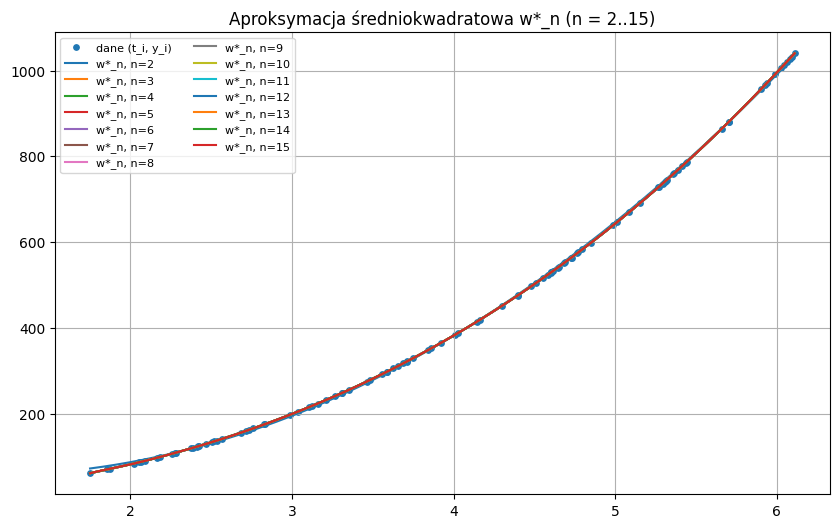

In [ ]:
idx = np.argsort(t)
t, y = t[idx], y[idx]

MAX_DEG = 15
m = len(t)

alpha = np.zeros(MAX_DEG + 1)
beta  = np.zeros(MAX_DEG + 1)
norm2 = np.zeros(MAX_DEG + 1) 

P_vals = []

Pkm1 = np.zeros(m)
Pk   = np.ones(m)

P_vals.append(Pk.copy())

norm2[0] = np.sum(Pk * Pk)
alpha[0] = np.sum(t * Pk * Pk) / norm2[0]

for k in range(0, MAX_DEG):
    if k == 0:
        Pkp1 = (t - alpha[0]) * Pk
    else:
        beta[k] = norm2[k] / norm2[k - 1]
        Pkp1 = (t - alpha[k]) * Pk - beta[k] * Pkm1

    P_vals.append(Pkp1.copy())
    norm2[k + 1] = np.sum(Pkp1 * Pkp1)
    alpha[k + 1] = np.sum(t * Pkp1 * Pkp1) / norm2[k + 1]

    Pkm1, Pk = Pk, Pkp1

def coeffs_ls(n):
    c = np.zeros(n + 1)
    for k in range(n + 1):
        c[k] = np.sum(y * P_vals[k]) / norm2[k]
    return c

def eval_wstar(x, c):
    x = np.asarray(x, float)
    n = len(c) - 1

    Pkm1 = np.zeros_like(x)
    Pk   = np.ones_like(x)

    w = c[0] * Pk
    if n == 0:
        return w

    Pkp1 = (x - alpha[0]) * Pk
    w += c[1] * Pkp1

    Pkm1, Pk = Pk, Pkp1

    for k in range(1, n):
        Pkp1 = (x - alpha[k]) * Pk - beta[k] * Pkm1
        w += c[k + 1] * Pkp1
        Pkm1, Pk = Pk, Pkp1

    return w

xgrid = np.linspace(t.min(), t.max(), 2000)

plt.figure(figsize=(10, 6))
plt.scatter(t, y, s=15, label="dane (t_i, y_i)")

for n in range(2, 16):
    c = coeffs_ls(n)
    w = eval_wstar(xgrid, c)
    plt.plot(xgrid, w, label=f"w*_n, n={n}")

plt.title("Aproksymacja średniokwadratowa w*_n (n = 2..15)")
plt.grid(True)
plt.legend(ncol=2, fontsize=8)
plt.show()